In [1]:
import numpy as np
import csv
import pandas as pd
from itertools import islice
import json
import missingno as msno
import matplotlib.pyplot as plt
import sklearn

In [2]:
# some tidying of the data 

books = pd.read_csv('../../data/data_with_author_and_awards.csv')

# apply data cleaning stuff 

%run ../../data/tidy_book_tags.ipynb # to get clean_filter_tags function

%run ../../data/tidy_publisher.ipynb # to get publisher_tidy function

books['first_publisher'] = publisher_tidy(books['first_publisher'])

books['tags'] = clean_filter_tags(books['tags'])

# combine awards into one target column

books['target'] = books['hugo'] | books['locus']

/tmp/ipykernel_25044/1892821212.py:3: DtypeWarning: Columns (0: isbn) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('../../data/data_with_author_and_awards.csv')


In [3]:
# do not want books from before awards
books = books[books['release_year'] >= 1970]

In [4]:
books.head()

,title_id,title,author,release_year,release_date,first_publisher,author_birthyear,author_birthplace,isbn,book_synopsis,...,locus,month_of_publication,Author_Age_at_Publication,Hugo_Awards_Previously,Locus_Awards_Previously,Hugo_Nominee_Before,Locus_Nominee_Before,author_birthplace_country,author_birthplace_continent,target
4100,689509.0,The Simultaneous Man,Ralph Blum,1970,1970-03-00,bantambooks,1932.0,"Los Angeles, California, USA",0553058789,NaN,...,False,03,38,0,0,False,False,USA,Central/North America,False
4101,2297062.0,The Three Straw Men,August Derleth,1970,1970-11-00,Other,1909.0,"Sauk City, Wisconsin, USA",0876860080,NaN,...,False,11,61,0,0,False,False,USA,Central/North America,False
4102,2499270.0,Witch's Suckling,Gimone Hall,1970,1970-09-00,manorbooks,NaN,NaN,NaN,NaN,...,False,09,Unknown,0,0,False,False,Unknown,Unknown,False
4103,531585.0,The Sorcerer's Skull,David Mason,1970,1970-00-00,lancerbooks,1924.0,NaN,1587150638,NaN,...,False,Unknown,46,0,0,False,False,Unknown,Unknown,False
4104,1984860.0,Bantan and the Mermaids,Maurice B. Gardner,1970,1970-00-00,Other,1905.0,"Portland, Maine, USA",NaN,NaN,...,False,Unknown,65,0,0,False,False,USA,Central/North America,False


<Axes: >

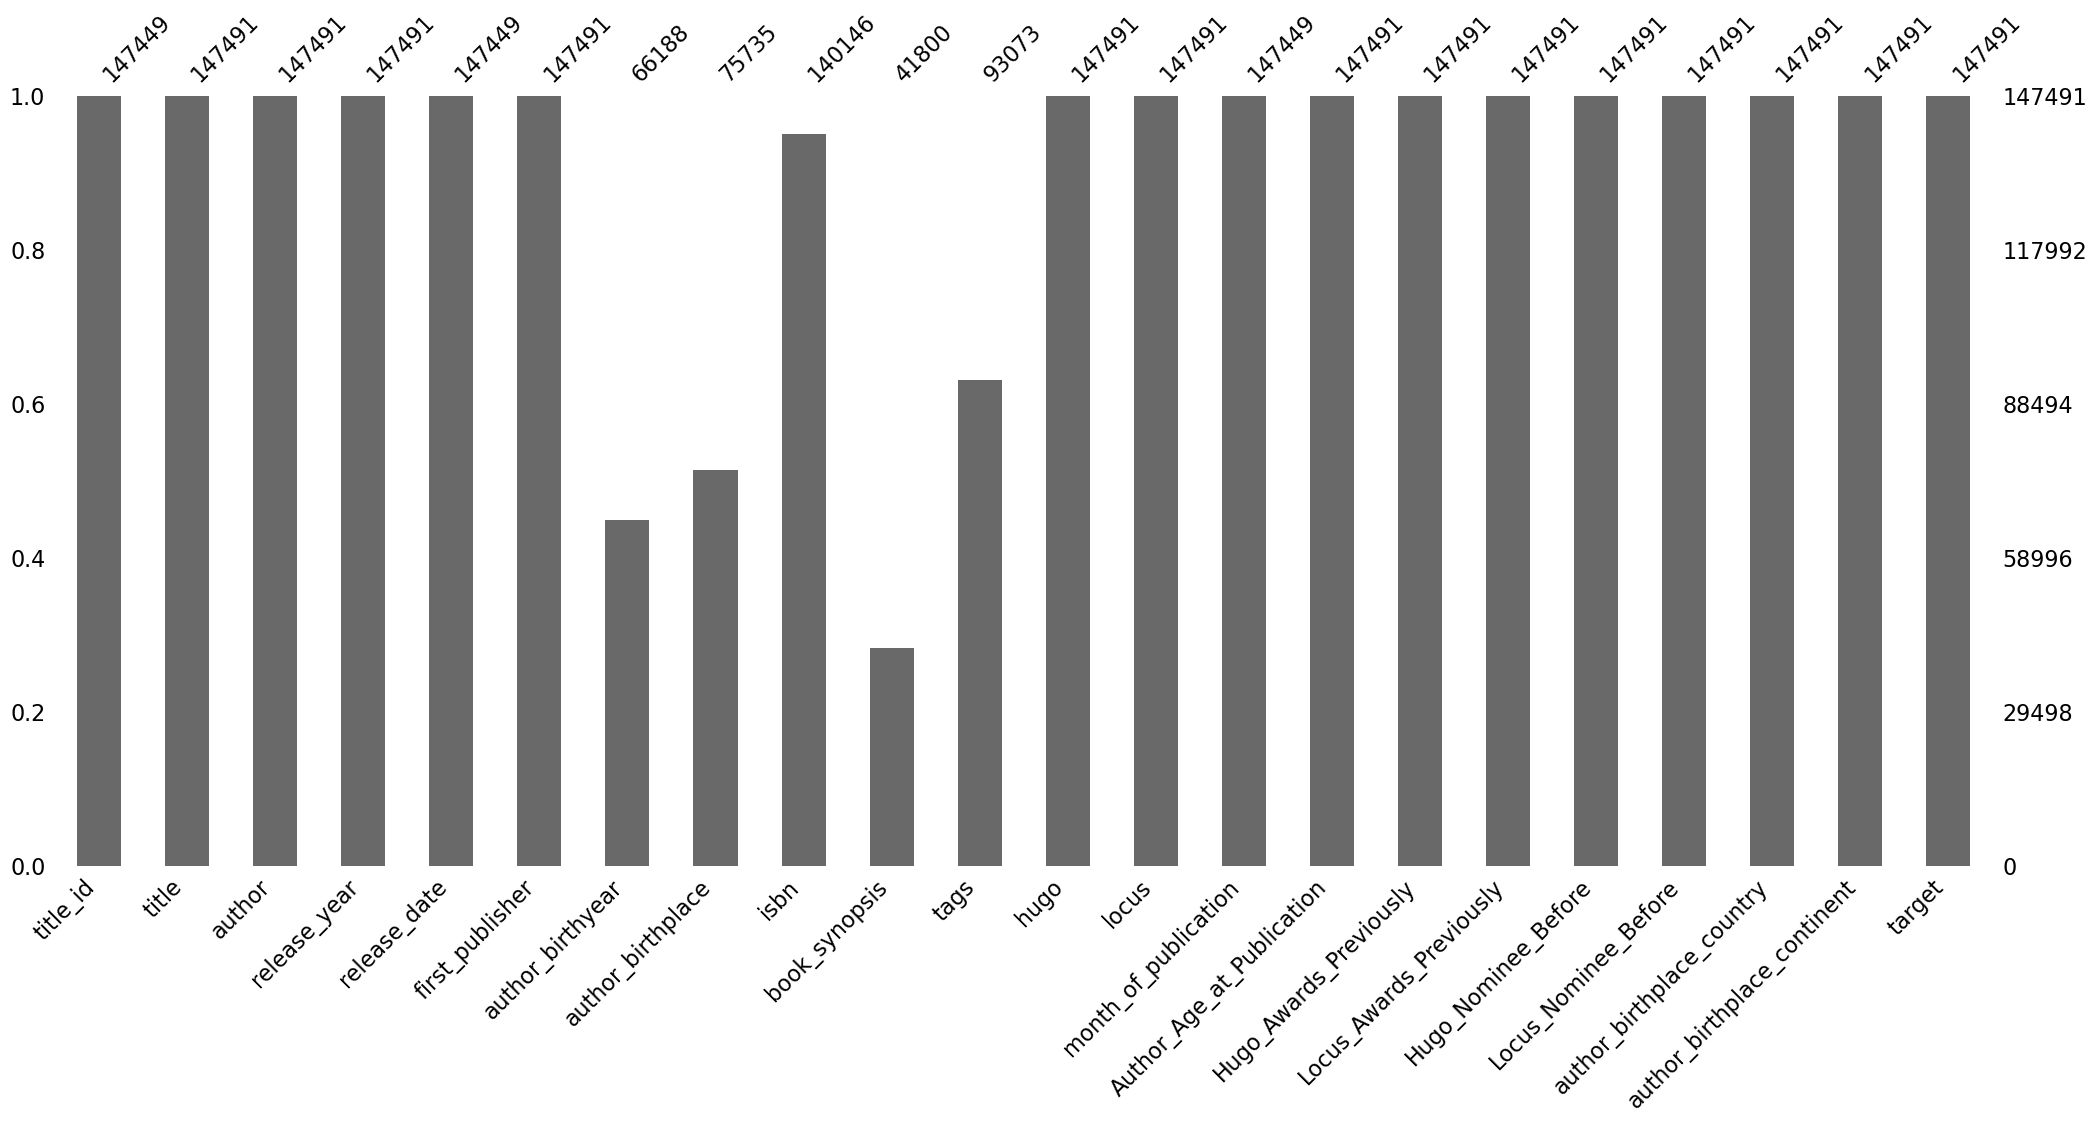

In [5]:
msno.bar(books)

In [6]:
# MISSINGNESS:
# for the sake of this notebook, we shall:
# - omit book synopses, title_id, isbn, release_date (captured in month), author_birthyear, author_birthplace (captured in country and continent)
# - and turn all empty tags into empty string ""

books = books.drop(["title_id", "isbn", "release_date", "author_birthyear", "book_synopsis", "author_birthplace"], axis=1)


In [7]:
baseline_cols = ['Author_Age_at_Publication', 'Hugo_Awards_Previously', 
                  'Locus_Awards_Previously', 'Hugo_Nominee_Before', 
                  'Locus_Nominee_Before', 'first_publisher', 'tags']

missing_counts = books[baseline_cols].isna().sum().sort_values(ascending=False)
missing_pct = (books[baseline_cols].isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    'missing_count': missing_counts,
    'missing_pct': missing_pct.round(2)
})
print(missing_summary)

                           missing_count  missing_pct
tags                               54418         36.9
Hugo_Awards_Previously                 0          0.0
Author_Age_at_Publication              0          0.0
Locus_Awards_Previously                0          0.0
Hugo_Nominee_Before                    0          0.0
Locus_Nominee_Before                   0          0.0
first_publisher                        0          0.0


In [8]:
print(books['tags'].apply(type).value_counts())

tags
<class 'list'>     93073
<class 'float'>    54418
Name: count, dtype: int64


In [9]:
books['tags'] = books['tags'].apply(lambda x: [] if isinstance(x, float) else x)

In [10]:
books['tags'] = books['tags'].apply(lambda x: [] if x == '' else x)

In [11]:
print(books['tags'].apply(type).value_counts())
#To ensure that each entry of tag is a list.

tags
<class 'list'>    147491
Name: count, dtype: int64


In [12]:
display(books['tags'])

4100                                                     []
4101                                                     []
4102                                                     []
4103                                              [fantasi]
4104                                                     []
                                ...                        
151586                              [ya, adventur, fantasi]
151587    [emot, fantasi, unloveable charact, dark, ten,...
151588                                                   []
151589                                             [ya, sf]
151590    [emot, a mix driven, not diverse charact, fant...
Name: tags, Length: 147491, dtype: object

<Axes: >

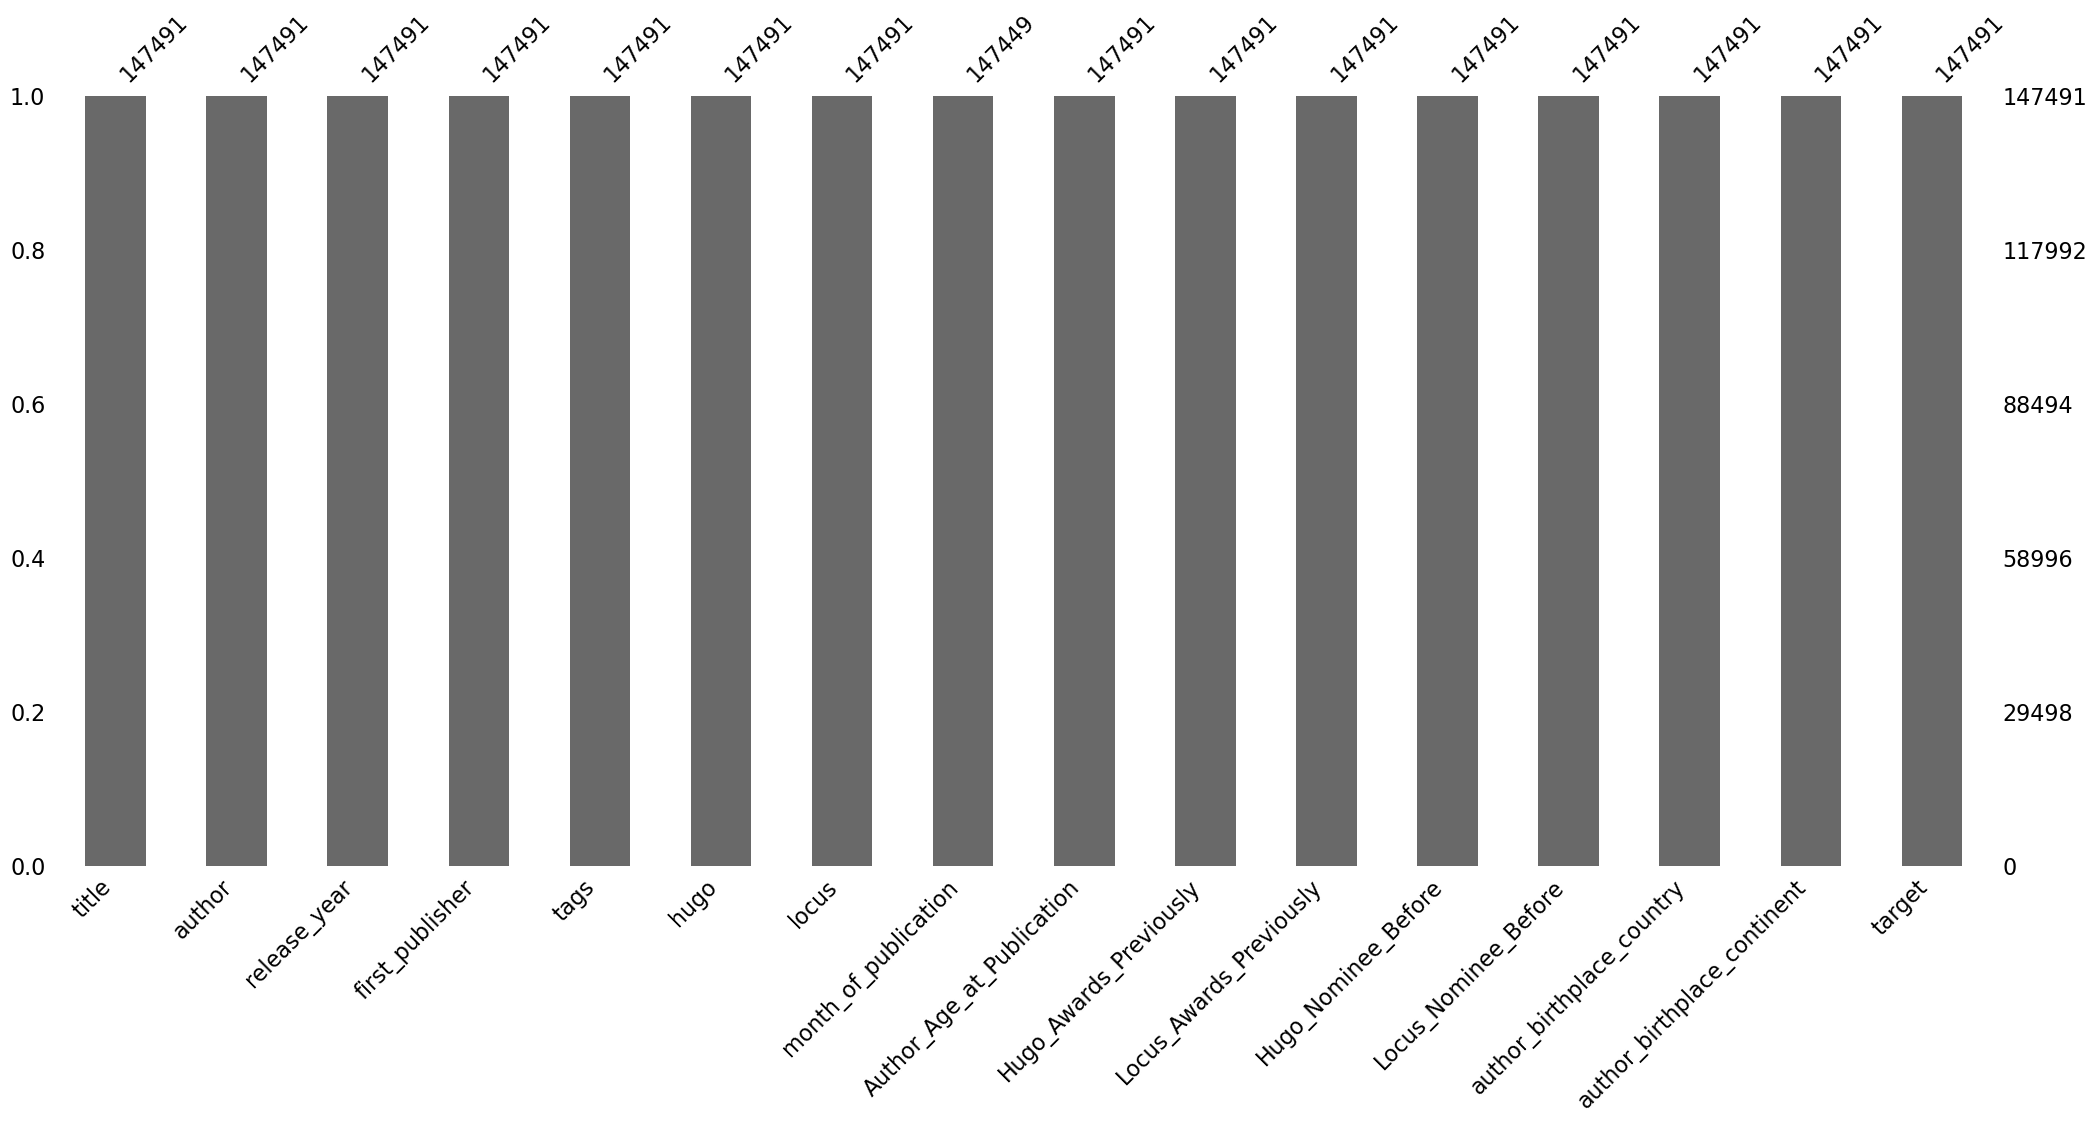

In [13]:
msno.bar(books)

In [14]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   title                        147491 non-null  str   
 1   author                       147491 non-null  str   
 2   release_year                 147491 non-null  int64 
 3   first_publisher              147491 non-null  str   
 4   tags                         147491 non-null  object
 5   hugo                         147491 non-null  bool  
 6   locus                        147491 non-null  bool  
 7   month_of_publication         147449 non-null  str   
 8   Author_Age_at_Publication    147491 non-null  str   
 9   Hugo_Awards_Previously       147491 non-null  int64 
 10  Locus_Awards_Previously      147491 non-null  int64 
 11  Hugo_Nominee_Before          147491 non-null  bool  
 12  Locus_Nominee_Before         147491 non-null  bool  
 13  author_birthplace_coun

In [15]:
books['Author_Age_at_Publication'] = pd.to_numeric(
    books['Author_Age_at_Publication'], errors='coerce'
)
#A lot of the 'Unknown' values are converted to NaN now

In [16]:
books['Author_Age_at_Publication']

4100      38.0
4101      61.0
4102       NaN
4103      46.0
4104      65.0
          ... 
151586     NaN
151587     NaN
151588    42.0
151589     NaN
151590     NaN
Name: Author_Age_at_Publication, Length: 147491, dtype: float64

In [17]:
books.info()

<class 'pandas.DataFrame'>
RangeIndex: 147491 entries, 4100 to 151590
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   title                        147491 non-null  str    
 1   author                       147491 non-null  str    
 2   release_year                 147491 non-null  int64  
 3   first_publisher              147491 non-null  str    
 4   tags                         147491 non-null  object 
 5   hugo                         147491 non-null  bool   
 6   locus                        147491 non-null  bool   
 7   month_of_publication         147449 non-null  str    
 8   Author_Age_at_Publication    66188 non-null   float64
 9   Hugo_Awards_Previously       147491 non-null  int64  
 10  Locus_Awards_Previously      147491 non-null  int64  
 11  Hugo_Nominee_Before          147491 non-null  bool   
 12  Locus_Nominee_Before         147491 non-null  bool   
 13  author_

In [18]:
books_tt = books[(books['release_year'] >= 1970) & (books['release_year'] < 2010)]
books_val = books[(books['release_year'] >= 2010) & (books['release_year'] < 2015)]

books_test = books[(books['release_year'] >= 2015)]


In [19]:
numerical_features = ["Hugo_Awards_Previously", "Locus_Awards_Previously"]
categorical_features = ["first_publisher", "month_of_publication", "author_birthplace_country", "author_birthplace_continent"]
mlb_features = ["tags"]
bool_features = ["Hugo_Nominee_Before", "Locus_Nominee_Before"]
#Author birthplace country and contintent might introduce double signals
#Fix month of publication to include it's cyclical effect.
#Author age at publication is not used so far. 

In [20]:
for col in numerical_features:
    books_tt[col] = books_tt[col].astype(float)

In [21]:
# fillna('') should be a no-op — compare before and after
before = books_tt['tags'].copy()
after = books_tt['tags'].fillna('')
print((before.apply(str) == after.apply(str)).all())  # should print True

True


In [22]:
## do multilabel binarizer of tags outside preprocessing. 
from sklearn.preprocessing import MultiLabelBinarizer

tag_labeler = MultiLabelBinarizer()
tag_labels = tag_labeler.fit_transform(books_tt['tags'])

# save as dataframe
tag_dataframe = pd.DataFrame(
    tag_labels,
    columns = ["tag_{}".format(tag) for tag in tag_labeler.classes_],
    index=books_tt.index
)

# concatenate to training dataframe
books_tt = pd.concat([books_tt, tag_dataframe], axis=1)

In [23]:
books_tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 47984 entries, 4100 to 52083
Columns: 132 entries, title to tag_zombi
dtypes: bool(5), float64(3), int64(117), object(1), str(6)
memory usage: 49.6+ MB


Custom Year by Year transformers built by Yilda

In [24]:
from numpy.random import randint
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import cosine_similarity

class YearByYearStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', scale_columns=None):
        self.scale_columns = scale_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X = X.copy()
        # apply standard scaler to each year group by group
        for year, data in X.groupby(by=self.year_column):
            imputer = SimpleImputer(strategy='mean')
            X.loc[data.index, self.scale_columns] = imputer.fit_transform(data[self.scale_columns])

            scaler = StandardScaler()
            #X.loc[data.index, self.scale_columns] = scaler.fit_transform(X.loc[data.index, self.scale_columns])
            #not using the imputed data here but can use it potentially
            X.loc[data.index, self.scale_columns] = scaler.fit_transform(data[self.scale_columns])
            #print(X.loc[data.index, self.scale_columns])
        return X.drop(columns=[self.year_column])
    
class YearlyGenreTagScaler(BaseEstimator, TransformerMixin):
    def __init__(self, year_column='year', tag_columns=None):
        self.tag_columns = tag_columns
        self.year_column = year_column

    def fit(self, X, y=None):
        self.is_fitted_ = True
        return self

    def transform(self, X, y=None):
        X = X.copy()

        similarity_series = pd.Series(dtype=float, index=X.index)

        for year, data in X.groupby(by=self.year_column):
            tag_data = data[self.tag_columns]
            similarity = cosine_similarity(tag_data)
            book_mean_similarity = np.mean(similarity, axis=0)
            similarity_series.loc[data.index] = book_mean_similarity

        X['cohort_similarity'] = similarity_series
        return X.drop(columns=[self.year_column])


In [25]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

categorical_pipeline = Pipeline(
    steps=[
        ('solve_nans', SimpleImputer(fill_value='Unknown', strategy='constant')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

tags_pipeline = Pipeline(
    steps=[
        ('similarity', YearlyGenreTagScaler(tag_columns=list(tag_dataframe.columns), year_column='release_year'))
    ]
)

feature_preprocessing = ColumnTransformer(
    transformers=[
        ('numerical_scaling', YearByYearStandardScaler(year_column='release_year', scale_columns=numerical_features), numerical_features + ['release_year']),
        ('onehot', categorical_pipeline, categorical_features),
        ('tag_similarity', tags_pipeline, list(tag_dataframe.columns) + ['release_year'])
    ],
    remainder='passthrough'
)


In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn import svm
from sklearn.base import clone
import xgboost as xgb
import lightgbm as lgb
#install lightgbm

models = {
    'dummy_mostfrequent': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='most_frequent'))
    ]
    ),
    'dummy_stratified': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='stratified'))
    ]
    ),
    'simple_classifier': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000))
    ]
    ),
    'simple_classifier_balanced': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
    ),
        'svc': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('svc', svm.SVC())
    ]
    ),

            'decision_tree': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('tree', tree.DecisionTreeClassifier())
    ]
    ),
    # xgb boost ranker with default hyperparams
            'xgb_rank': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('xgb_rank', xgb.XGBRanker(tree_method="hist", lambdarank_num_pair_per_sample=8, objective="rank:ndcg", lambdarank_pair_method="topk"))
    ]
    ),
 
}

In [27]:
## implementing different time series splitting

# Sliding Window (Rolling Cross-Validation): train on past few years

def sliding_window_split(data, train_window_size=10, val_size=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)

    window_splits = []

    for i in range(num_years - train_window_size - val_size + 1):
        window_start = i
        window_end = i + train_window_size
        val_start = window_end
        val_end = val_start + val_size

        window = data[data['release_year'].isin(years[window_start:window_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        window_splits.append((window, val))

    return window_splits




In [28]:
books_val = books[(books['release_year'] >= 2010) & (books['release_year'] < 2015)]

tags_binarized = tag_labeler.transform(books_val['tags'].fillna(''))
tags_df = pd.DataFrame(
tags_binarized, 
columns=[f"tag_{c}" for c in tag_labeler.classes_],
index=books_val.index
)
books_val = pd.concat([books_val, tags_df], axis=1)

for col in numerical_features:
    books_val[col] = books_val[col].astype(float)
#jay: there is a bug here in yilda's code
additional_scores = {}
preds = {}

/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:1016: UserWarning: unknown class(es) ['standalon', 'supervillain'] will be ignored
  warnings.warn(


In [29]:
from sklearn.metrics import ndcg_score

def precision_at_k(df, score_col, target_col='target', year_col='release_year', k=6):
    """Mean, across years, of (# true finalists in top-k predicted) / k."""
    precisions = []
    for year, group in df.groupby(year_col):
        top_k = group.nlargest(k, score_col)
        precisions.append(top_k[target_col].sum() / k)
    return np.mean(precisions)

def ndcg_at_k(df, score_col, target_col='target', year_col='release_year', k=6):
    """Mean, across years, of NDCG@k -- rewards correct ranking, not just membership."""
    scores = []
    for year, group in df.groupby(year_col):
        if len(group) < 2 or group[target_col].sum() == 0:
            continue  # ndcg undefined with <2 items or no positives that year
        y_true = group[target_col].astype(int).values.reshape(1, -1)   
        # bool -> int because ndcg needs to sort it
        y_score = group[score_col].astype(float).values.reshape(1, -1)  # just in case
        scores.append(ndcg_score(y_true, y_score, k=k))
    return np.mean(scores)

In [30]:
def get_scores(model, name, X):
    """Return a continuous per-row score usable for top-k ranking, regardless of model type."""
    if 'rank' in name:
        return model.predict(X)
    elif hasattr(model.named_steps[list(model.named_steps.keys())[-1]], 'predict_proba'):
        return model.predict_proba(X)[:, 1]
    else:
        return model.decision_function(X)

=== dummy_mostfrequent ===
Mean f1-score: 0.0; Max: 0.0; Min: 0.0
=== dummy_stratified ===
Mean f1-score: 0.04044861319233617; Max: 0.09090909090909091; Min: 0.0
=== simple_classifier ===
Mean f1-score: 0.35951475438680003; Max: 0.5217391304347826; Min: 0.21875
=== simple_classifier_balanced ===
Mean f1-score: 0.29110692696978174; Max: 0.35874439461883406; Min: 0.23140495867768596
=== svc ===
Mean f1-score: 0.3422610375386249; Max: 0.4857142857142857; Min: 0.23333333333333334
=== decision_tree ===
Mean f1-score: 0.3518488578220287; Max: 0.5274725274725275; Min: 0.1839080459770115
=== xgb_rank ===
Mean f1-score: 0.4356935910726993; Max: 0.5652173913043478; Min: 0.2857142857142857


Text(0.5, 1.0, 'nested time CV, sliding window (rolling cross-validation) of 15 years')

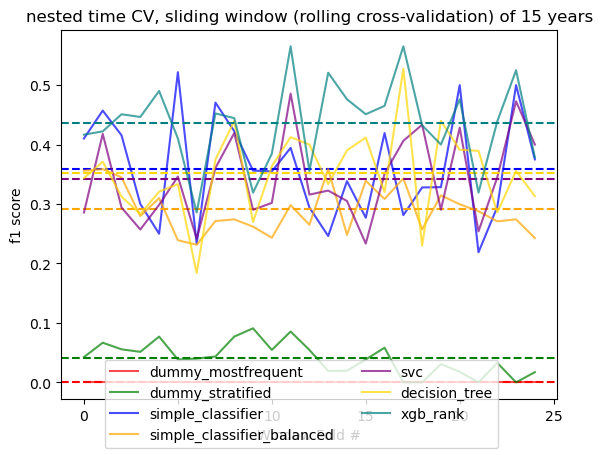

In [31]:
windows = sliding_window_split(books_tt, train_window_size=15)

colors = ['red', 'green', 'blue', 'orange', 'purple', 'gold', 'teal']

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year']

i = 0

fig = plt.figure()

for name, model in models.items():
    print("=== {} ===".format(name))

    mean_score = 0
    scores = []

    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1]


        if name == 'xgb_rank':

            model.fit(book_train[features], book_train['target'], xgb_rank__qid=book_train['release_year'])

            num_finalists = int(book_val['target'].sum())

            ypred = model.predict(book_val[features])

            # pick the top books to be finalists: check against number of finalists in the dataset 
            book_data_copy = book_val
            book_data_copy['predicted'] = ypred
            finalists = book_data_copy.groupby('release_year')['predicted'].nlargest(num_finalists).index.droplevel(0)

            book_val['predicted'] = 0
            book_val.loc[finalists, 'predicted'] = 1

            ypred = book_val['predicted']

        else:
            model.fit(book_train[features], book_train['target'])

            ypred = model.predict(book_val[features])


        score = f1_score(book_val['target'], ypred)

        scores.append(score)

        tn, fp, fn, tp = confusion_matrix(book_val['target'], ypred).ravel().tolist()

        # print(" Fold {}: f1-score of {}, tp: {}, fn: {}".format(num + 1, score, tp, fn))

        mean_score += score / len(windows)

    print("Mean f1-score: {}; Max: {}; Min: {}".format(mean_score, max(scores), min(scores)))

    plt.plot(list(range(len(windows))), scores, label = name, alpha = 0.7, color=colors[i])
    plt.axhline(mean_score, color=colors[i], linestyle='dashed')
    i += 1

plt.xlabel("Window Fold #")
plt.ylabel("f1 score")

fig.legend(loc="lower center", ncol = 2)
plt.title("nested time CV, sliding window (rolling cross-validation) of 15 years")


In [32]:
# Walk-Forward Validation: re-train on increasingly larger training set

def walk_forward(data, initial_size=5, step=1):
    # data is a data
    years = data['release_year'].unique()
    num_years = len(years)
    splits = []

    for i in range(initial_size, num_years - initial_size - step + 1):
        # print(num_years - initial_size - step + 1)
        data_start = 0
        data_end = i
        val_start = data_end
        val_end = val_start + step
        print()

        window = data[data['release_year'].isin(years[data_start:data_end])]
        val = data[data['release_year'].isin(years[val_start:val_end])]

        splits.append((window, val))

    return splits


In [33]:
models_2 = {
    
    'dummy_mostfrequent': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='most_frequent'))
    ]
    ),
    'dummy_stratified': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('modelling', DummyClassifier(strategy='stratified'))
    ]
    ),
    'simple_classifier': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000))
    ]
    ),
    'simple_classifier_balanced': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced'))
    ]
    ),
        'svc': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('svc', svm.SVC(kernel='rbf', class_weight='balanced'))
    ]
        ),
        'svc_yearweighted': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('svc_yearweighted', svm.SVC(kernel='rbf', class_weight='balanced'))
    ]
    ),

            'decision-tree': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('tree', tree.DecisionTreeClassifier())
    ]
    ),
    # xgb boost ranker with default hyperparams
            'xgb_rank': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('xgb_rank', xgb.XGBRanker(tree_method="hist", lambdarank_num_pair_per_sample=8, objective="rank:ndcg", lambdarank_pair_method="topk"))
    ]
    ),
   # lightgbm lambdarank ranker with default-ish hyperparams
    'lgb_rank': Pipeline(steps=[
        ('preprocess', clone(feature_preprocessing)),
        ('lgb_rank', lgb.LGBMRanker(
            objective='lambdarank',
            metric='ndcg',
            n_estimators=200,
            learning_rate=0.05,
            num_leaves=31,
            verbosity=-1
        ))
    ]
    ),
    

}

windows = sliding_window_split(books_tt, train_window_size=15)

results = {name: {'f1': [], 'precision@6': [], 'ndcg@6': []} for name in models_2}

colors = ['red', 'green', 'blue', 'orange', 'purple', 'gold', 'teal', 'black', 'magenta']

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year']

i = 0

for name, model in models_2.items():
    print("=== {} ===".format(name))

    for num, fold in enumerate(windows):
        book_train = fold[0]
        book_val = fold[1].copy()

        if name == 'svc_yearweighted':
            model.fit(book_train[features], book_train['target'],
                      svc_yearweighted__sample_weight=np.exp(-0.5 * (max(book_train['release_year']) - book_train['release_year'])))
            score = model.predict(book_val[features])

        elif name == 'xgb_rank':
            model.fit(book_train[features], book_train['target'], xgb_rank__qid=book_train['release_year'])
            score = model.predict(book_val[features])

        elif name == 'lgb_rank':
            book_train_sorted = book_train.sort_values('release_year')
            group_sizes = book_train_sorted.groupby('release_year').size().values
            assert book_train_sorted['release_year'].is_monotonic_increasing
            model.fit(book_train_sorted[features], book_train_sorted['target'],
                       lgb_rank__group=group_sizes)
            score = model.predict(book_val[features])

        else:
            model.fit(book_train[features], book_train['target'])
            score = get_scores(model, name, book_val[features])

        book_val['score'] = score

        # convert to binary top-k-per-year for F1, same convention as xgb_rank used originally
        num_finalists = int(book_val['target'].sum())
        top_idx = book_val.groupby('release_year')['score'].nlargest(num_finalists).index.droplevel(0)
        book_val['predicted'] = 0
        book_val.loc[top_idx, 'predicted'] = 1

        results[name]['f1'].append(f1_score(book_val['target'], book_val['predicted']))
        results[name]['precision@6'].append(precision_at_k(book_val, 'score'))
        results[name]['ndcg@6'].append(ndcg_at_k(book_val, 'score'))

    print("Mean F1: {:.3f}  Mean Precision@6: {:.3f}  Mean NDCG@6: {:.3f}".format(
        np.mean(results[name]['f1']),
        np.mean(results[name]['precision@6']),
        np.mean(results[name]['ndcg@6'])
    ))

=== dummy_mostfrequent ===
Mean F1: 0.026  Mean Precision@6: 0.020  Mean NDCG@6: 0.033
=== dummy_stratified ===
Mean F1: 0.027  Mean Precision@6: 0.020  Mean NDCG@6: 0.033
=== simple_classifier ===
Mean F1: 0.434  Mean Precision@6: 0.613  Mean NDCG@6: 0.618
=== simple_classifier_balanced ===
Mean F1: 0.424  Mean Precision@6: 0.533  Mean NDCG@6: 0.544
=== svc ===
Mean F1: 0.309  Mean Precision@6: 0.280  Mean NDCG@6: 0.291
=== svc_yearweighted ===
Mean F1: 0.253  Mean Precision@6: 0.200  Mean NDCG@6: 0.270
=== decision-tree ===
Mean F1: 0.337  Mean Precision@6: 0.260  Mean NDCG@6: 0.348
=== xgb_rank ===
Mean F1: 0.436  Mean Precision@6: 0.740  Mean NDCG@6: 0.756
=== lgb_rank ===


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(
/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/va

Mean F1: 0.478  Mean Precision@6: 0.780  Mean NDCG@6: 0.804


/home/rudolph/miniconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


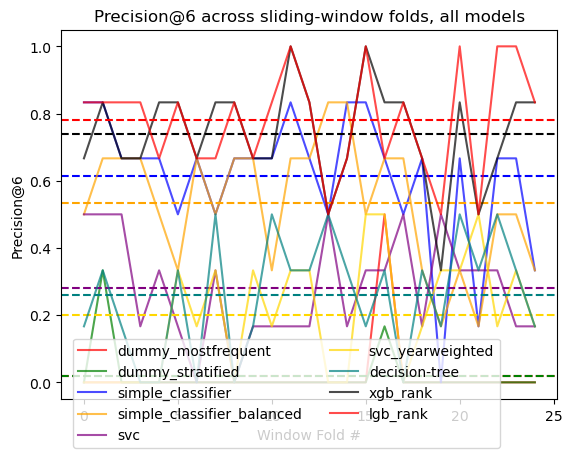

In [34]:
colors = ['red', 'green', 'blue', 'orange', 'purple', 'gold', 'teal', 'black']

fig = plt.figure()
for i, (name, res) in enumerate(results.items()):
    plt.plot(range(len(res['precision@6'])), res['precision@6'], label=name, alpha=0.7, color=colors[i % len(colors)])
    plt.axhline(np.mean(res['precision@6']), color=colors[i % len(colors)], linestyle='dashed')

plt.xlabel("Window Fold #")
plt.ylabel("Precision@6")
fig.legend(loc="lower center", ncol=2)
plt.title("Precision@6 across sliding-window folds, all models")
plt.show()

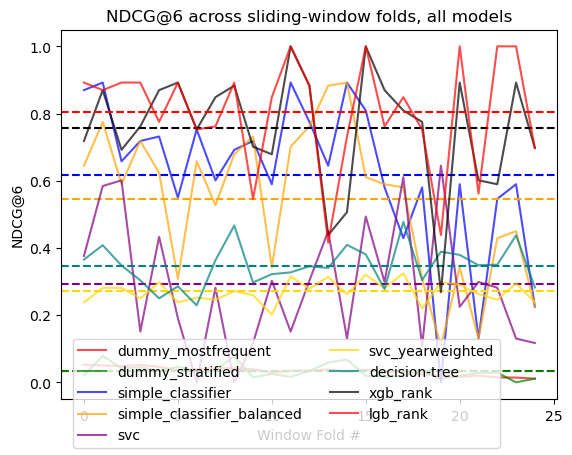

In [35]:
fig = plt.figure()
for i, (name, res) in enumerate(results.items()):
    plt.plot(range(len(res['ndcg@6'])), res['ndcg@6'], label=name, alpha=0.7, color=colors[i % len(colors)])
    plt.axhline(np.mean(res['ndcg@6']), color=colors[i % len(colors)], linestyle='dashed')

plt.xlabel("Window Fold #")
plt.ylabel("NDCG@6")
fig.legend(loc="lower center", ncol=2)
plt.title("NDCG@6 across sliding-window folds, all models")
plt.show()

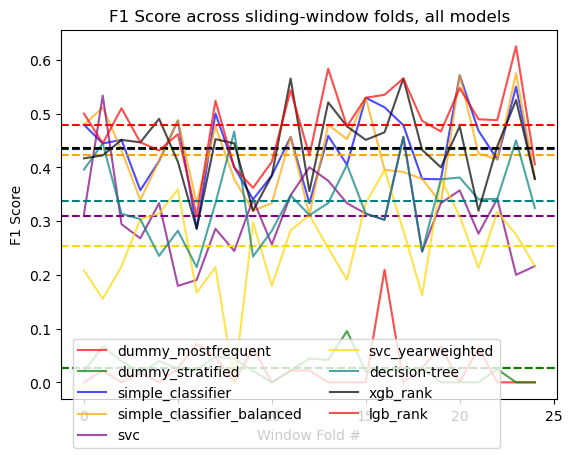

In [36]:
fig = plt.figure()
for i, (name, res) in enumerate(results.items()):
    plt.plot(range(len(res['f1'])), res['f1'], label=name, alpha=0.7, color=colors[i % len(colors)])
    plt.axhline(np.mean(res['f1']), color=colors[i % len(colors)], linestyle='dashed')

plt.xlabel("Window Fold #")
plt.ylabel("F1 Score")
fig.legend(loc="lower center", ncol=2)
plt.title("F1 Score across sliding-window folds, all models")
plt.show()

Now, we only look at the last four models

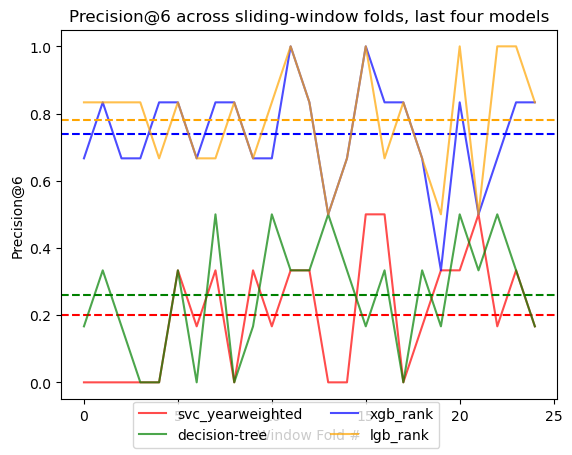

In [37]:
fig = plt.figure()
for i, (name, res) in enumerate(list(results.items())[-4:]):
    plt.plot(range(len(res['precision@6'])), res['precision@6'], label=name, alpha=0.7, color=colors[i % len(colors)])
    plt.axhline(np.mean(res['precision@6']), color=colors[i % len(colors)], linestyle='dashed')

plt.xlabel("Window Fold #")
plt.ylabel("Precision@6")
fig.legend(loc="lower center", ncol=2)
plt.title("Precision@6 across sliding-window folds, last four models")
plt.show()

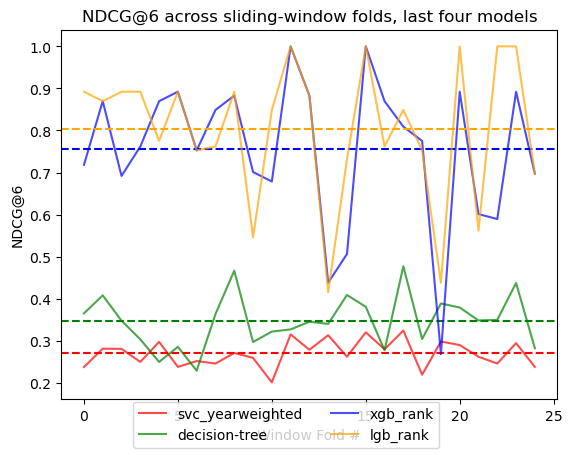

In [38]:
fig = plt.figure()
for i, (name, res) in enumerate(list(results.items())[-4:]):
    plt.plot(range(len(res['ndcg@6'])), res['ndcg@6'], label=name, alpha=0.7, color=colors[i % len(colors)])
    plt.axhline(np.mean(res['ndcg@6']), color=colors[i % len(colors)], linestyle='dashed')

plt.xlabel("Window Fold #")
plt.ylabel("NDCG@6")
fig.legend(loc="lower center", ncol=2)
plt.title("NDCG@6 across sliding-window folds, last four models")
plt.show()

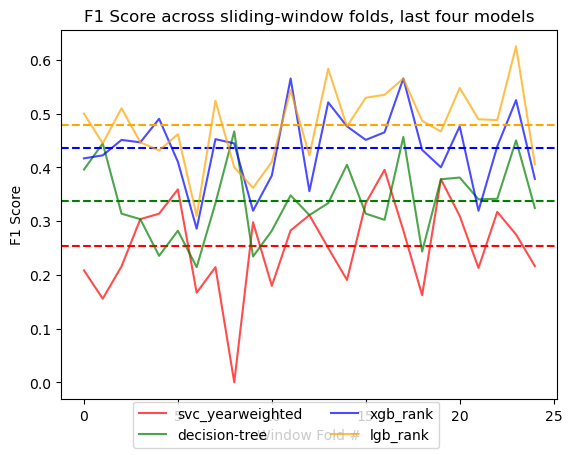

In [39]:
fig = plt.figure()
for i, (name, res) in enumerate(list(results.items())[-4:]):
    plt.plot(range(len(res['f1'])), res['f1'], label=name, alpha=0.7, color=colors[i % len(colors)])
    plt.axhline(np.mean(res['f1']), color=colors[i % len(colors)], linestyle='dashed')

plt.xlabel("Window Fold #")
plt.ylabel("F1 Score")
fig.legend(loc="lower center", ncol=2)
plt.title("F1 Score across sliding-window folds, last four models")
plt.show()